In [ ]:
%matplotlib inline

In [ ]:
import keras
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,7) # Make the figures a bit bigger
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Conv2D, MaxPooling2D, Flatten
from keras import backend as K

In [ ]:
# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# input image dimensions
_, img_rows, img_cols = x_train.shape

x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1) # Reshape (60000, 28, 28) -> (60000, 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)


# from uint8 (0-255) to float32 to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
n_classes = 10
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, n_classes)   # y_train = [array of numbers from 1 to 10]  ->   array of 10d vectors with 1 on the place of the digit, and 0 on the other ones
y_test = keras.utils.to_categorical(y_test, n_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
from keras.layers import AveragePooling2D

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu',
                        padding='same', input_shape=input_shape))
model.add(Dropout(0.25))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(Dropout(0.25))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Dropout(0.25))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Dropout(0.25))
model.add(AveragePooling2D(pool_size=(7, 7)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(n_classes, activation='softmax'))
model.compile(loss='categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 1, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,650 (611.91 KB)

 Trainable params: 156,650 (611.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(x_train, y_train,
          batch_size=128,
          epochs=10,
          verbose=1,
          validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 322s 680ms/step - accuracy: 0.4959 - loss: 1.3775 - val_accuracy: 0.9544 - val_loss: 0.1864
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 345s 735ms/step - accuracy: 0.9360 - loss: 0.2191 - val_accuracy: 0.9738 - val_loss: 0.1064
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 355s 679ms/step - accuracy: 0.9596 - loss: 0.1412 - val_accuracy: 0.9811 - val_loss: 0.0693
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 345s 729ms/step - accuracy: 0.9705 - loss: 0.1040 - val_accuracy: 0.9864 - val_loss: 0.0505
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 341s 641ms/step - accuracy: 0.9743 - loss: 0.0945 - val_accuracy: 0.9905 - val_loss: 0.0387
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 300s 640ms/step - accuracy: 0.9790 - loss: 0.0747 - val_accuracy: 0.9864 - val_loss: 0.0492
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 311s 664ms/step - accuracy: 0.9826 - loss: 0.0586 - val_accuracy: 0.9920 - val_loss: 0.0323
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 343s 708ms/step - accuracy: 0.9846 -

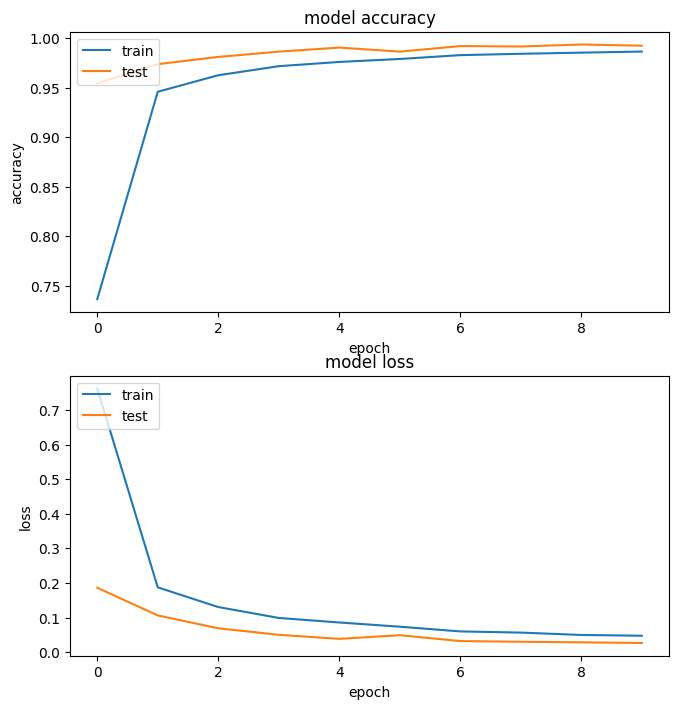

In [ ]:
plt.figure()
plt.subplot(2,1,1)
plt.tight_layout()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

plt.subplot(2,1,2)
plt.tight_layout()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

plt.show()

In [ ]:
def shift_image(image, dx, dy):
    '''
    Сдвигает изображение на dx пикселей вправо и dy пикселей вниз.
    Пустые области заполняются нулями (черным).
    '''
    if len(image.shape) == 3:        # (28,28,1) -> (28,28)
        image = image.squeeze()

    h, w = image.shape
    shifted = np.zeros_like(image)

    # shifted image
    x_start = max(0, dx)
    x_end = min(w, w + dx)
    y_start = max(0, dy)
    y_end = min(h, h + dy)

    # original image
    or_x_start = max(0, -dx)
    or_x_end = min(w, w - dx)
    or_y_start = max(0, -dy)
    or_y_end = min(h, h - dy)


    shifted[y_start:y_end, x_start:x_end] = image[or_y_start:or_y_end, or_x_start:or_x_end]

    return shifted.reshape(28, 28, 1)

In [ ]:
right_shifts_acc = {}
print("\nCдвиги вправо:")
for dx in range(0, 15):
    x_test_shifted_right = np.zeros_like(x_test)
    for i in range(len(x_test)):
        x_test_shifted_right[i] = shift_image(x_test[i], dx, 0)

    score = model.evaluate(x_test_shifted_right, y_test, verbose=0)
    right_shifts_acc[dx] = score[1]
    print(f'Сдвиг вправо на {dx} пикселей: accuracy = {score[1]:.4f}')


Cдвиги вправо:
Сдвиг вправо на 0 пикселей: accuracy = 0.9924
Сдвиг вправо на 1 пикселей: accuracy = 0.9919
Сдвиг вправо на 2 пикселей: accuracy = 0.9922
Сдвиг вправо на 3 пикселей: accuracy = 0.9919
Сдвиг вправо на 4 пикселей: accuracy = 0.9919
Сдвиг вправо на 5 пикселей: accuracy = 0.9903
Сдвиг вправо на 6 пикселей: accuracy = 0.9867
Сдвиг вправо на 7 пикселей: accuracy = 0.9764
Сдвиг вправо на 8 пикселей: accuracy = 0.9600
Сдвиг вправо на 9 пикселей: accuracy = 0.9292
Сдвиг вправо на 10 пикселей: accuracy = 0.8906
Сдвиг вправо на 11 пикселей: accuracy = 0.8440
Сдвиг вправо на 12 пикселей: accuracy = 0.7759
Сдвиг вправо на 13 пикселей: accuracy = 0.6668
Сдвиг вправо на 14 пикселей: accuracy = 0.5272


In [ ]:
test_accuracies = {}
max_shift = 10

for shift in range(0, max_shift + 1):
    x_test_shifted = np.zeros_like(x_test)  # empty, the same size as x_test

    for i in range(len(x_test)):
        dx = np.random.randint(-shift, shift + 1)  # random shift in [-shift, shift +1] 'cause  np.random.randint(a, b) gets a =< N < b
        dy = np.random.randint(-shift, shift + 1)
        x_test_shifted[i] = shift_image(x_test[i], dx, dy)

    score = model.evaluate(x_test_shifted, y_test, verbose=0)
    test_accuracies[shift] = score[1]
    print(f'Случайный сдвиг до {shift} пикселей: accuracy = {score[1]:.4f}')

Случайный сдвиг до 0 пикселей: accuracy = 0.9924
Случайный сдвиг до 1 пикселей: accuracy = 0.9908
Случайный сдвиг до 2 пикселей: accuracy = 0.9896
Случайный сдвиг до 3 пикселей: accuracy = 0.9862
Случайный сдвиг до 4 пикселей: accuracy = 0.9858
Случайный сдвиг до 5 пикселей: accuracy = 0.9801
Случайный сдвиг до 6 пикселей: accuracy = 0.9715
Случайный сдвиг до 7 пикселей: accuracy = 0.9531
Случайный сдвиг до 8 пикселей: accuracy = 0.9343
Случайный сдвиг до 9 пикселей: accuracy = 0.8985
Случайный сдвиг до 10 пикселей: accuracy = 0.8546


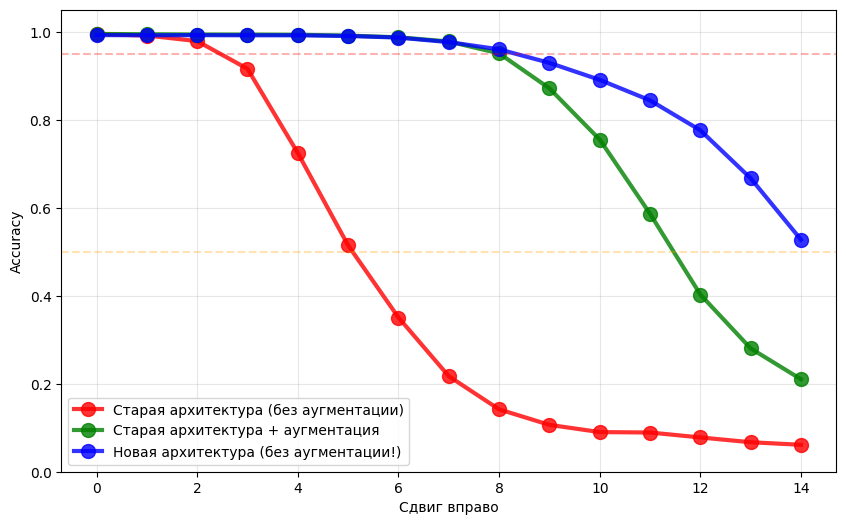

In [ ]:
original_acc = [0.9946, 0.9914, 0.9787, 0.9158, 0.7244, 0.5144, 0.3505, 0.2171, 0.1417, 0.1065, 0.0901, 0.0891, 0.0779, 0.0670, 0.0612]
augmented_acc = [0.9949, 0.9943, 0.9936, 0.9935, 0.9930, 0.9912, 0.9873, 0.9778, 0.9508, 0.8713, 0.7548, 0.5861, 0.4025, 0.2802, 0.2101]
better_arch_acc = [0.9924, 0.9919, 0.9922, 0.9919, 0.9919, 0.9903, 0.9867, 0.9764, 0.9600, 0.9292, 0.8906, 0.8440, 0.7759, 0.6668, 0.5272]

plt.figure(figsize=(10, 6))

plt.plot(range(15), original_acc, 'ro-', linewidth=3, markersize=10, label='Старая архитектура (без аугментации)', alpha=0.8)
plt.plot(range(15), augmented_acc, 'go-', linewidth=3, markersize=10, label='Старая архитектура + аугментация', alpha=0.8)
plt.plot(range(15), better_arch_acc, 'bo-', linewidth=3, markersize=10, label='Новая архитектура (без аугментации!)', alpha=0.8)

plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.3)
plt.axhline(y=0.50, color='orange', linestyle='--', alpha=0.3)
plt.xlabel('Сдвиг вправо')
plt.ylabel('Accuracy')
plt.title('')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

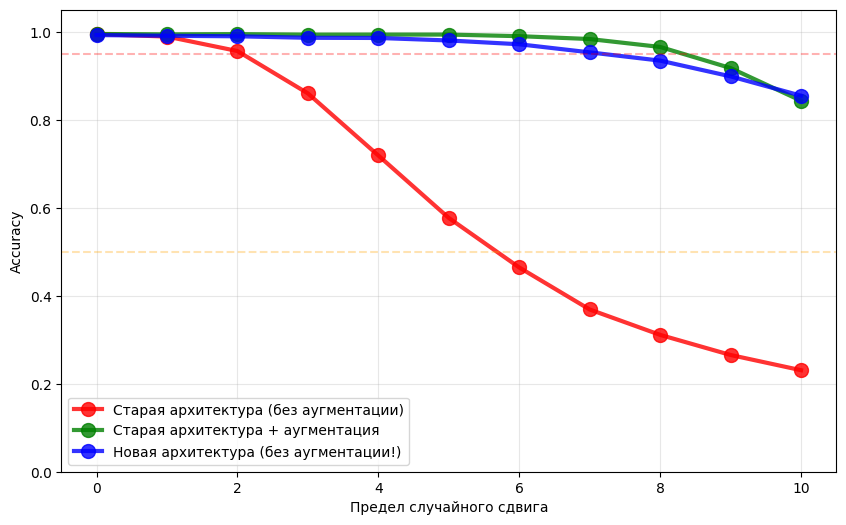

In [ ]:
original_acc = [0.9946, 0.9890, 0.9561, 0.8599, 0.7187, 0.5768, 0.4642, 0.3687, 0.3110, 0.2653, 0.2307]
augmented_acc = [0.9949, 0.9940, 0.9945, 0.9934, 0.9935, 0.9935, 0.9899, 0.9834, 0.9654, 0.9174, 0.8431]
better_arch_acc = [0.9924, 0.9908, 0.9896, 0.9862, 0.9858, 0.9801, 0.9715, 0.9531, 0.9343, 0.8985, 0.8546]

plt.figure(figsize=(10, 6))

plt.plot(range(11), original_acc, 'ro-', linewidth=3, markersize=10, label='Старая архитектура (без аугментации)', alpha=0.8)
plt.plot(range(11), augmented_acc, 'go-', linewidth=3, markersize=10, label='Старая архитектура + аугментация', alpha=0.8)
plt.plot(range(11), better_arch_acc, 'bo-', linewidth=3, markersize=10, label='Новая архитектура (без аугментации!)', alpha=0.8)

plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.3)
plt.axhline(y=0.50, color='orange', linestyle='--', alpha=0.3)
plt.xlabel('Предел случайного сдвига')
plt.ylabel('Accuracy')
plt.title('')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

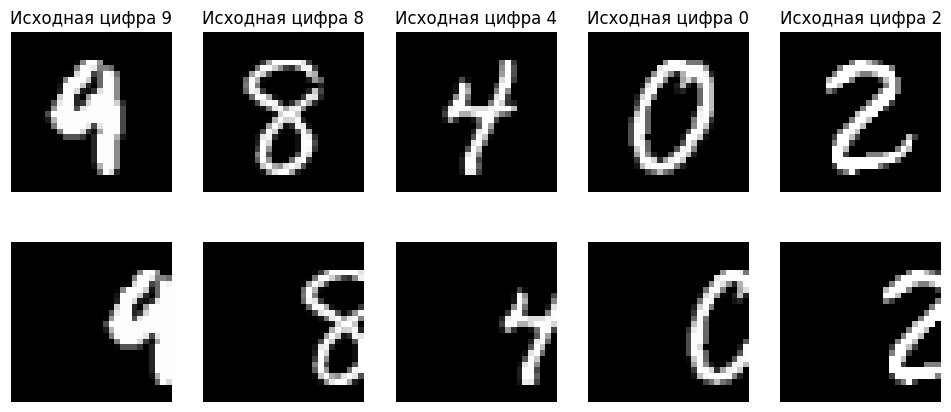

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
example_indices = np.random.choice(len(x_test), 5, replace=False)

for i, idx in enumerate(example_indices):
    axes[0, i].imshow(x_test[idx].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Исходная цифра {np.argmax(y_test[idx])}')
    axes[0, i].axis('off')

    shifted = shift_image(x_test[idx], 10, 0)
    axes[1, i].imshow(shifted.squeeze(), cmap='gray')
    axes[1, i].axis('off')

plt.show()